In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from pandas.plotting import scatter_matrix

plt.style.use('classic')

In [2]:
df=pd.read_csv('.././housing.csv',sep=',')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


# **Sumarização estatística: medidas de localização e dispersão**

In [4]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


**Adicionando medidas de dispersão:**
1.   Intervalo ou range.
2.   Coeficiente de variação.
3.   Kurtosis ou Coeficiente de Assimetria.
4.   Skewness ou Coeficiente de assimetria.





In [5]:
# obtendo a lista de nomes das features do dataset:
cols=df.columns.to_list()
cols

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value',
 'ocean_proximity']

In [6]:
dt=df.describe()
dt.loc['cv']=dt.loc['std'].values/dt.loc['mean'].values # adição do coeficiente de variação (cv)
dt.loc['range']=(df[cols[:-1]].max()-df[cols[:-1]].min()).values # adição do intervalo (range)
dt.loc['skewness']=df[cols[:-1]].skew(axis=0).values # adição do coeficiente de assimetria (medida de forma)
dt.loc['kurtosis']=df[cols[:-1]].kurt(axis=0).values # adição do coeficiente de curtose (medida de forma)
dt.round(2)
dt

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000
cv,-0.016756,0.059945,0.439448,0.827698,0.783432,0.794444,0.765364,0.490825,0.557855
range,10.040000,9.410000,51.000000,39318.000000,6444.000000,35679.000000,6081.000000,14.500200,485002.000000


In [7]:
dt.loc[['count','mean','std','cv','min','25%','50%','75%','max','skewness','kurtosis']]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
cv,-0.016756,0.059945,0.439448,0.827698,0.783432,0.794444,0.765364,0.490825,0.557855
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000
skewness,-0.297801,0.465953,0.060331,4.147343,3.459546,4.935858,3.410438,1.646657,0.977763


**Rotacionando a Tabela de Sumarização**

In [8]:
dt.loc[['count','mean','std','cv','min','25%','50%','75%','max','skewness','kurtosis']].T.round(2)

,count,mean,std,cv,min,25%,50%,75%,max,skewness,kurtosis
longitude,20640.0,-119.57,2.00,-0.02,-124.35,-121.80,-118.49,-118.01,-114.31,-0.30,-1.33
latitude,20640.0,35.63,2.14,0.06,32.54,33.93,34.26,37.71,41.95,0.47,-1.12
housing_median_age,20640.0,28.64,12.59,0.44,1.00,18.00,29.00,37.00,52.00,0.06,-0.80
total_rooms,20640.0,2635.76,2181.62,0.83,2.00,1447.75,2127.00,3148.00,39320.00,4.15,32.63
total_bedrooms,20433.0,537.87,421.39,0.78,1.00,296.00,435.00,647.00,6445.00,3.46,21.99
population,20640.0,1425.48,1132.46,0.79,3.00,787.00,1166.00,1725.00,35682.00,4.94,73.55
households,20640.0,499.54,382.33,0.77,1.00,280.00,409.00,605.00,6082.00,3.41,22.06
median_income,20640.0,3.87,1.90,0.49,0.50,2.56,3.53,4.74,15.00,1.65,4.95
median_house_value,20640.0,206855.82,115395.62,0.56,14999.00,119600.00,179700.00,264725.00,500001.00,0.98,0.33


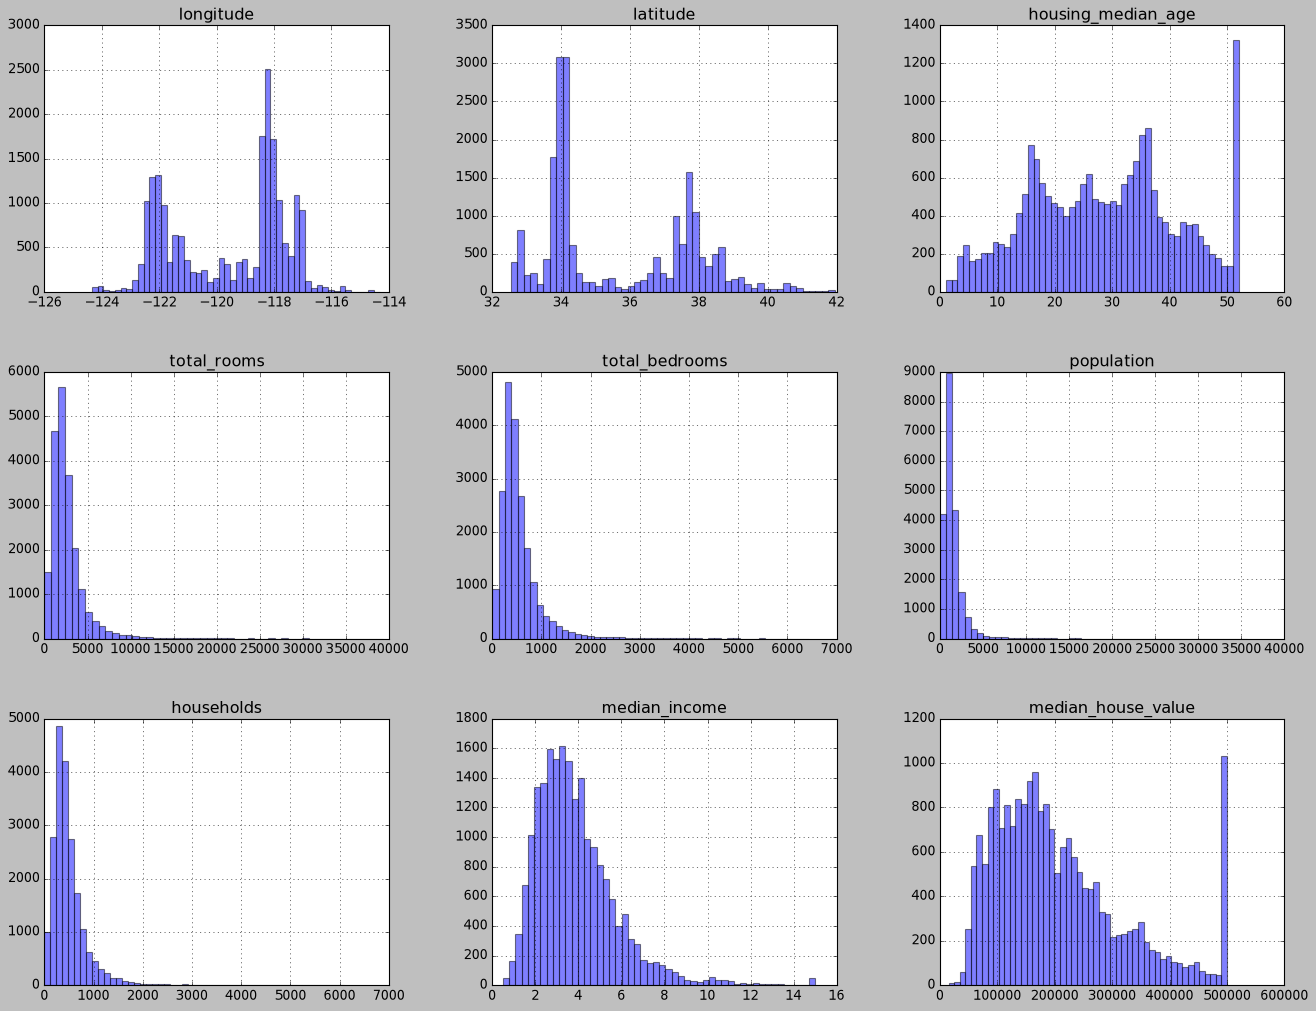

In [9]:
df.hist(bins=50,figsize=(20,15), alpha=0.5)
plt.show()

# **Análise de correlação: medidas de associação**

In [10]:
df[cols[:-1]].corr("pearson").round(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.00,-0.92,-0.11,0.04,0.07,0.10,0.06,-0.02,-0.05
latitude,-0.92,1.00,0.01,-0.04,-0.07,-0.11,-0.07,-0.08,-0.14
housing_median_age,-0.11,0.01,1.00,-0.36,-0.32,-0.30,-0.30,-0.12,0.11
total_rooms,0.04,-0.04,-0.36,1.00,0.93,0.86,0.92,0.20,0.13
total_bedrooms,0.07,-0.07,-0.32,0.93,1.00,0.88,0.98,-0.01,0.05
population,0.10,-0.11,-0.30,0.86,0.88,1.00,0.91,0.00,-0.02
households,0.06,-0.07,-0.30,0.92,0.98,0.91,1.00,0.01,0.07
median_income,-0.02,-0.08,-0.12,0.20,-0.01,0.00,0.01,1.00,0.69
median_house_value,-0.05,-0.14,0.11,0.13,0.05,-0.02,0.07,0.69,1.00


In [11]:
df[cols[:-1]].corr("spearman").round(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.00,-0.88,-0.15,0.04,0.06,0.12,0.06,-0.01,-0.07
latitude,-0.88,1.00,0.03,-0.02,-0.06,-0.12,-0.07,-0.09,-0.17
housing_median_age,-0.15,0.03,1.00,-0.36,-0.31,-0.28,-0.28,-0.15,0.07
total_rooms,0.04,-0.02,-0.36,1.00,0.92,0.82,0.91,0.27,0.21
total_bedrooms,0.06,-0.06,-0.31,0.92,1.00,0.87,0.98,-0.01,0.09
population,0.12,-0.12,-0.28,0.82,0.87,1.00,0.90,0.01,0.00
households,0.06,-0.07,-0.28,0.91,0.98,0.90,1.00,0.03,0.11
median_income,-0.01,-0.09,-0.15,0.27,-0.01,0.01,0.03,1.00,0.68
median_house_value,-0.07,-0.17,0.07,0.21,0.09,0.00,0.11,0.68,1.00


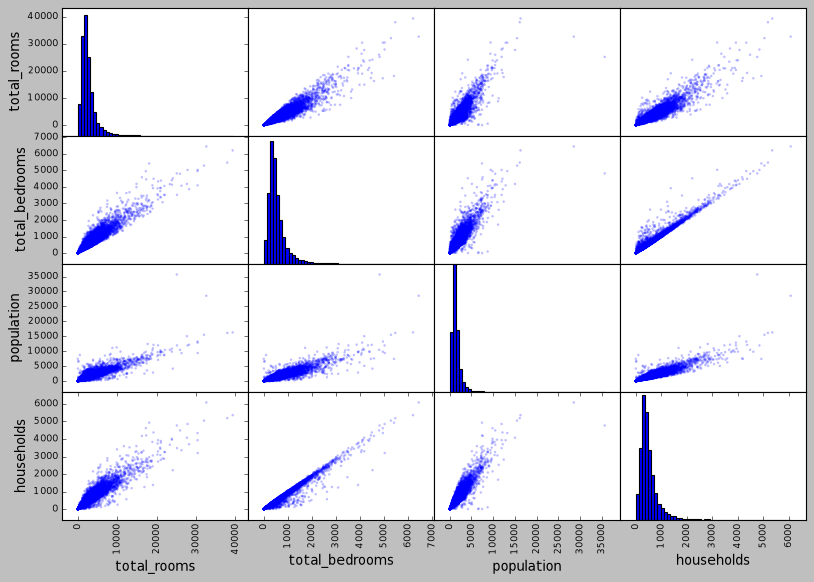

In [12]:
attributes=["total_rooms","total_bedrooms","population","households"]

scatter_matrix(df[attributes], figsize=(12, 8),range_padding=0.2,color='blue',
               hist_kwds={'bins':50,'color':'blue','alpha':1.0},alpha=0.25)
plt.show()

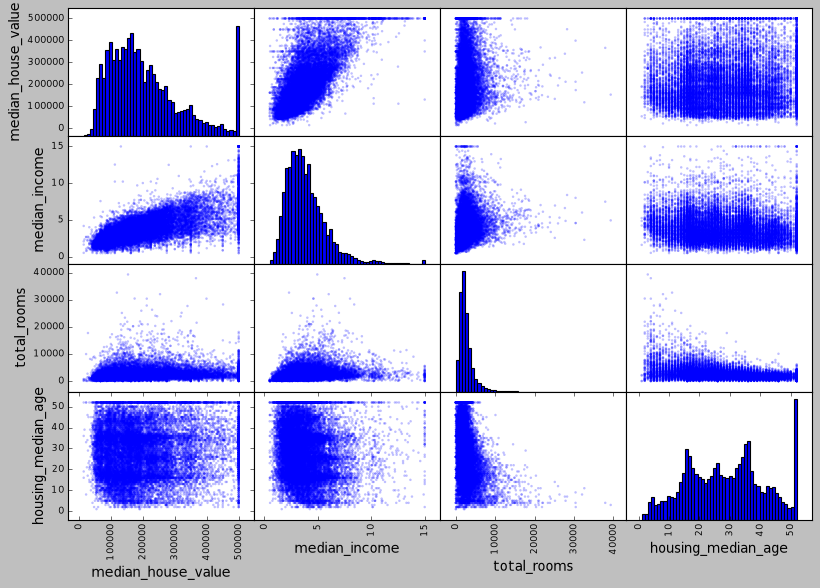

In [13]:
attributes=["median_house_value", "median_income", "total_rooms","housing_median_age"]

scatter_matrix(df[attributes], figsize=(12, 8),range_padding=0.2,color='blue',
               hist_kwds={'bins':50,'color':'blue','alpha':1.0},alpha=0.25)
plt.show()

# **Visualização de Dados**

**`Histogramas com Gráfico de Densidade`**

ModuleNotFoundError: No module named 'scipy'

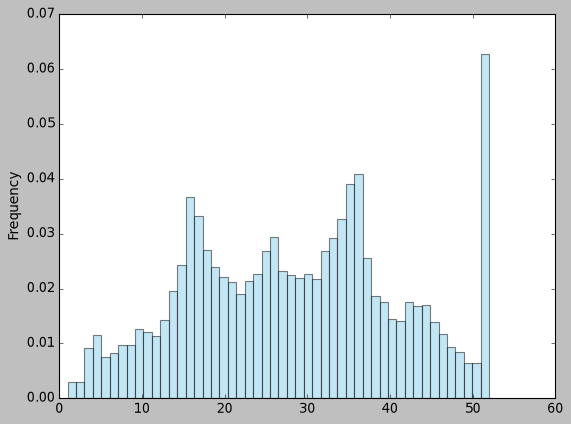

In [14]:
for col_feature in cols[2:-1]:
    # Gerando o gráfico histograma
    ax = df[col_feature].plot(kind="hist",color='skyblue', edgecolor='black', density=True, bins=50, alpha=0.5)

    # Sobrepondo o gráfico de densidade no mesmo eixo (ax=ax)
    df[col_feature].plot(kind='kde', ax=ax, color='red', linewidth=2)

    # Personalizando algumas configurações do gráfico
    plt.title('Histograma e Gráfico de Densidade')
    plt.xlabel(col_feature)
    plt.ylabel('Densidade')
    plt.grid(axis='y', alpha=0.3)
    plt.xlim(0, df[col_feature].max()*1.1)

    plt.show()

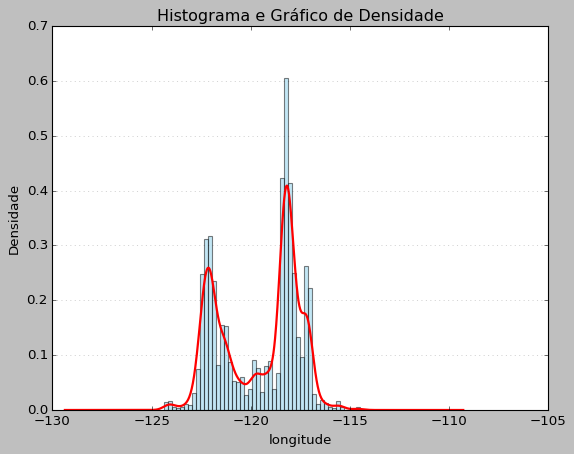

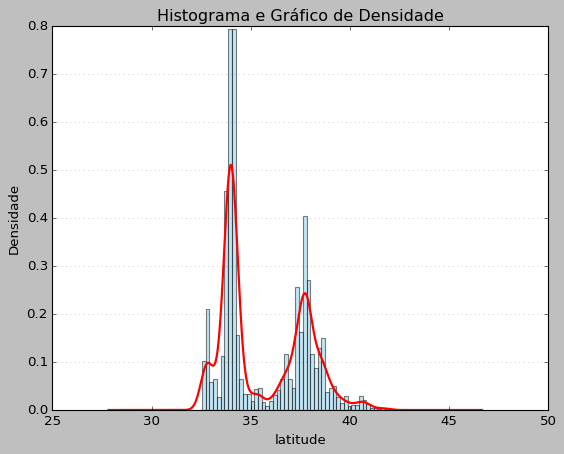

In [ ]:
for col_feature in cols[:2]:
    # Gerando o gráfico histograma
    ax = df[col_feature].plot(kind="hist",color='skyblue', edgecolor='black', density=True, bins=50, alpha=0.5)

    # Sobrepondo o gráfico de densidade no mesmo eixo (ax=ax)
    df[col_feature].plot(kind='kde', ax=ax, color='red', linewidth=2)

    # Personalizando algumas configurações do gráfico
    plt.title('Histograma e Gráfico de Densidade')
    plt.xlabel(col_feature)
    plt.ylabel('Densidade')
    plt.grid(axis='y', alpha=0.3)

    plt.show()

**`Gráfico da Função de Distribuição Acumulada`**

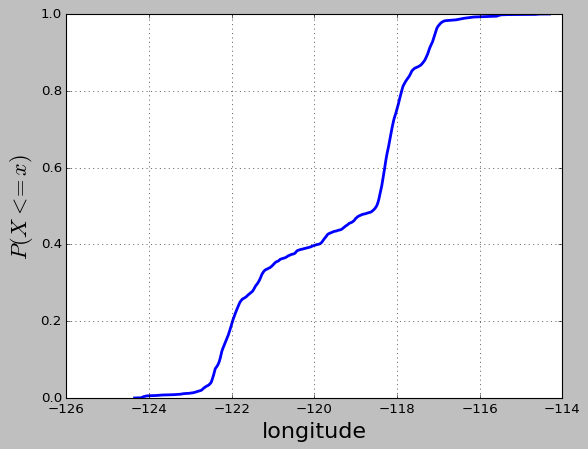

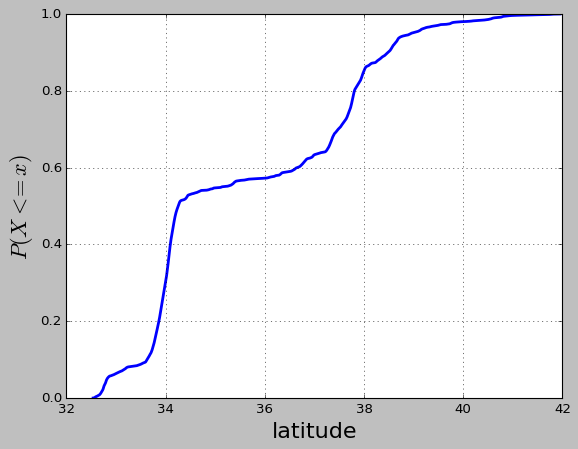

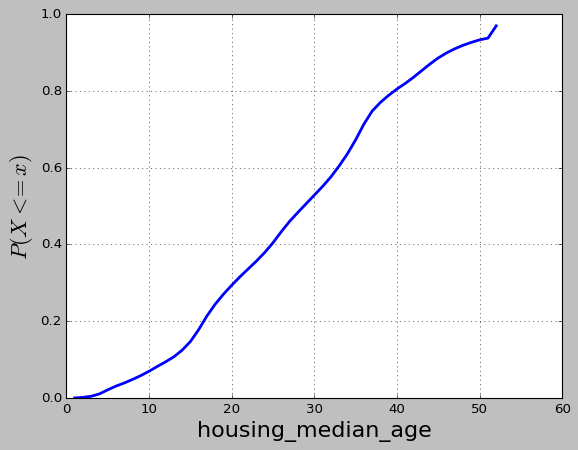

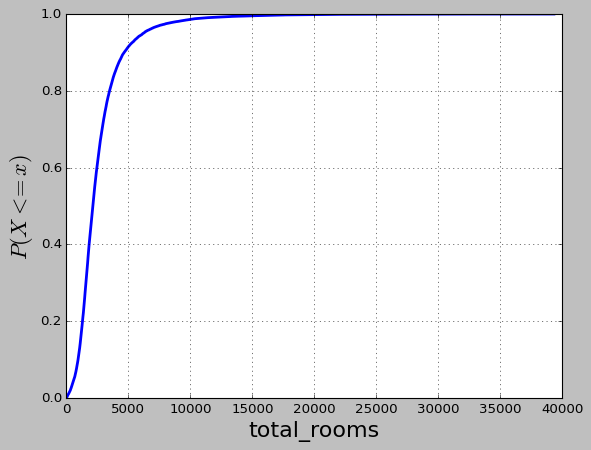

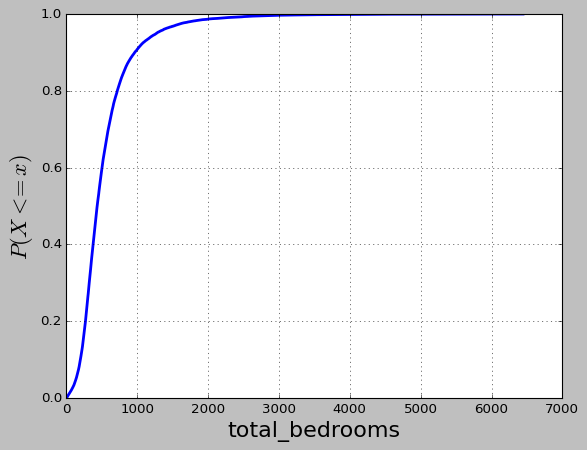

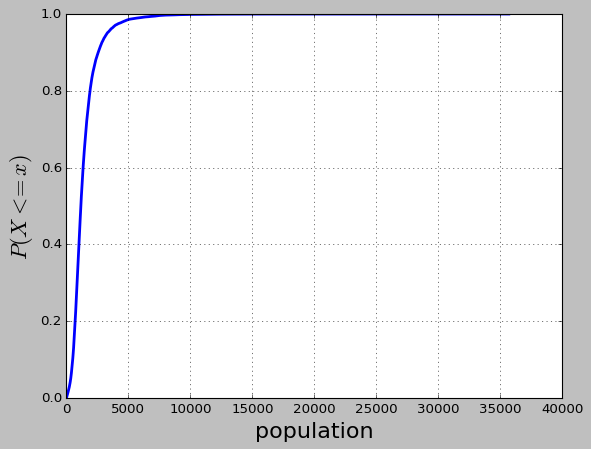

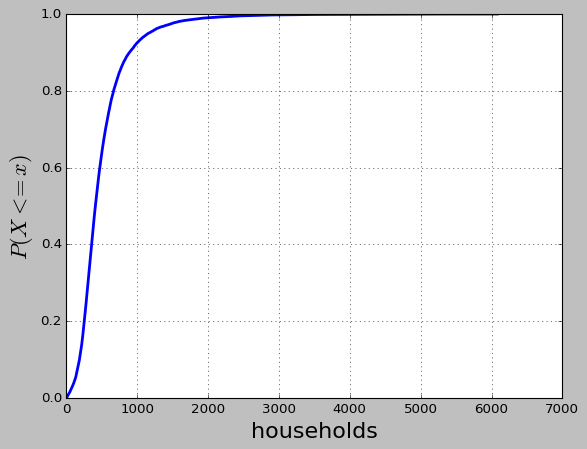

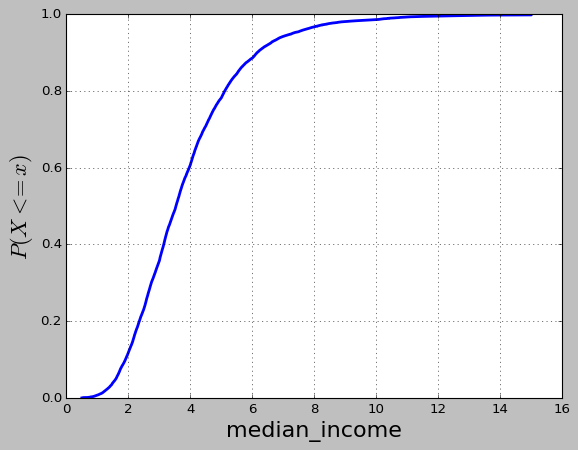

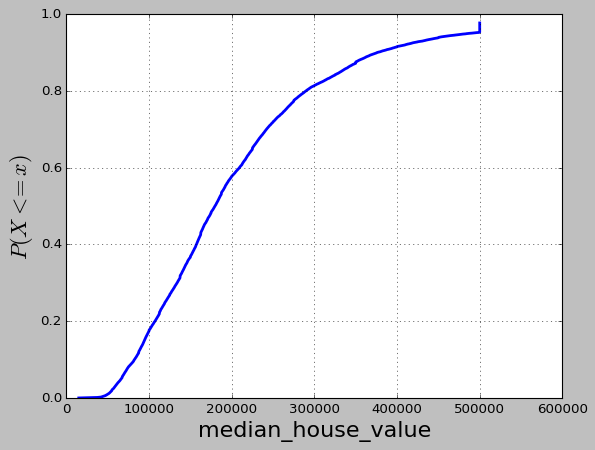

In [ ]:
df_cdf = df.copy()

# Set global label font size before plotting
plt.rcParams['axes.labelsize'] = 20

for feature in cols[:-1]:
  df_cdf[feature+'_rank'] = df_cdf[feature].rank(method='average', pct = True)
  df_cdf.sort_values(feature).plot(x = feature, y = feature+'_rank',grid=True, color='blue', lw=2.5, legend=False)

  plt.ylabel(r"$P(X <\!\!= x)$")
  plt.draw()

**`Gráfico de Caixas`**

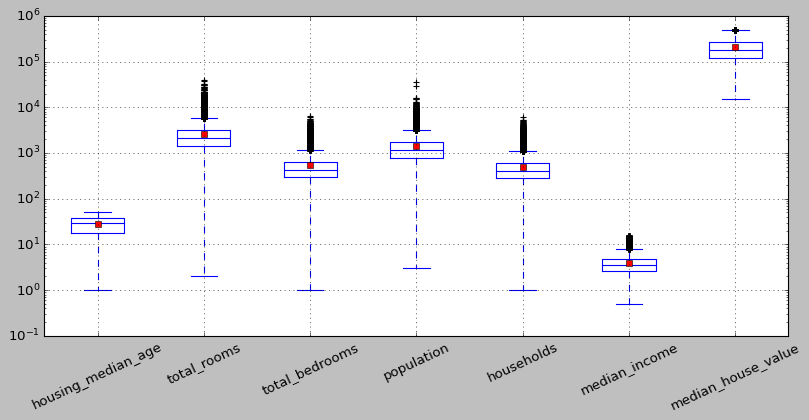

In [ ]:
df[cols[2:-1]].boxplot(color='blue',showmeans=True,figsize=(12,5))
plt.xticks(rotation=25)
plt.yscale('log')
plt.show()

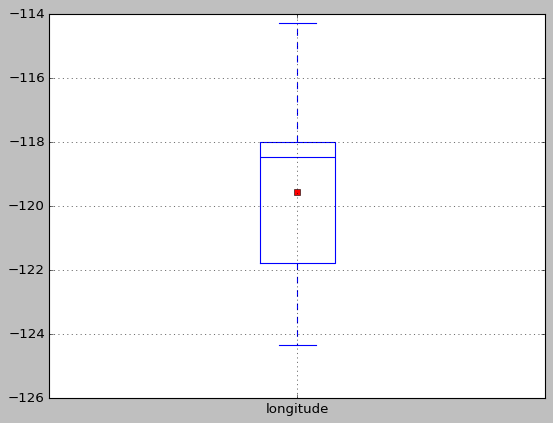

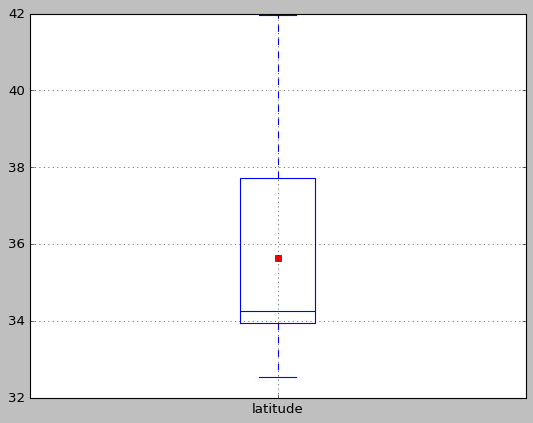

In [ ]:
for feature in cols[:2]:
  df[[feature]].boxplot(color='blue',showmeans=True)

  plt.show()

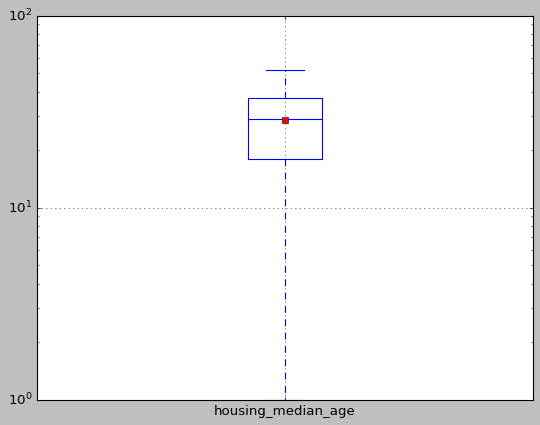

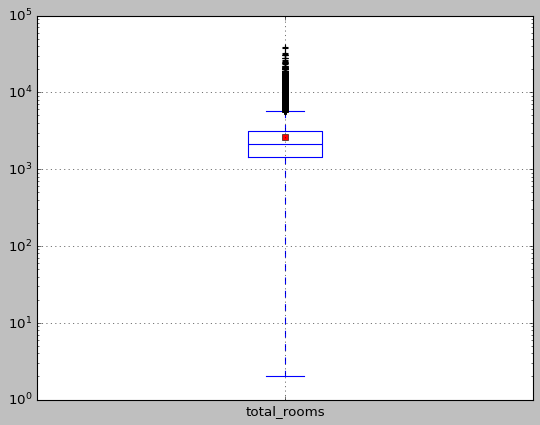

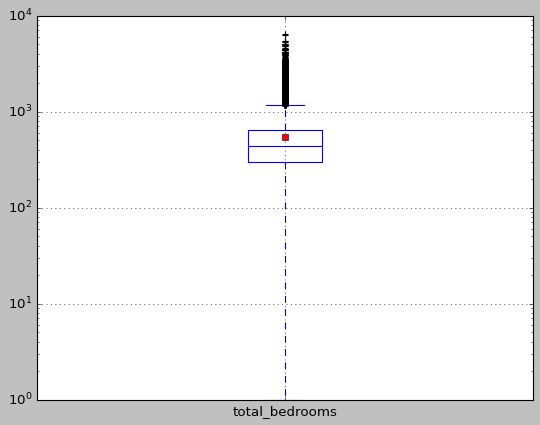

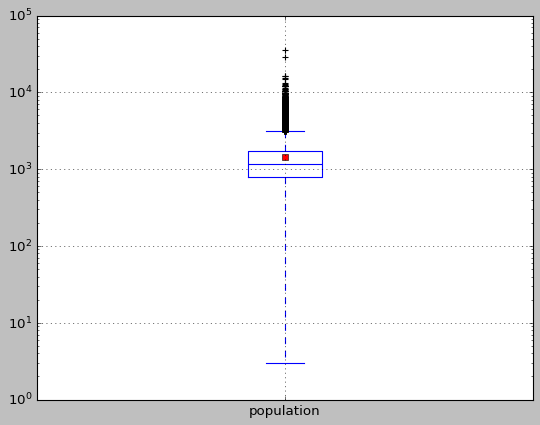

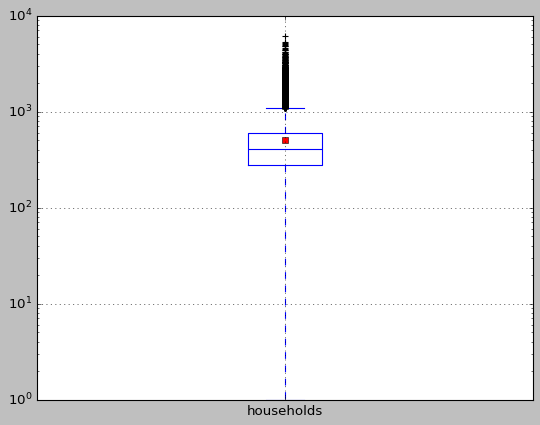

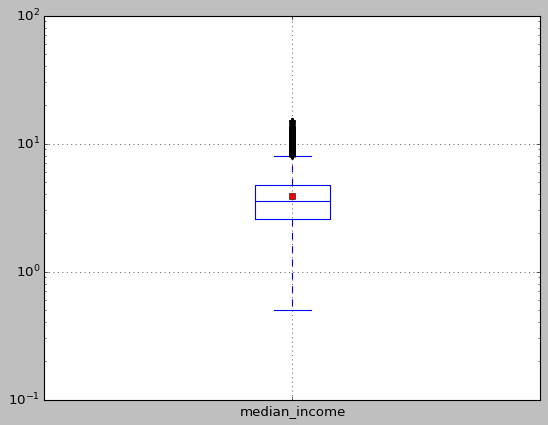

In [ ]:
# Gerando cada boxplot separadamente
for feature in cols[2:-2]:
  df[[feature]].boxplot(color='blue',showmeans=True)
  plt.yscale('log')
  plt.show()

**`Gráfico de Dispersão`**

<Axes: xlabel='median_house_value', ylabel='median_income'>

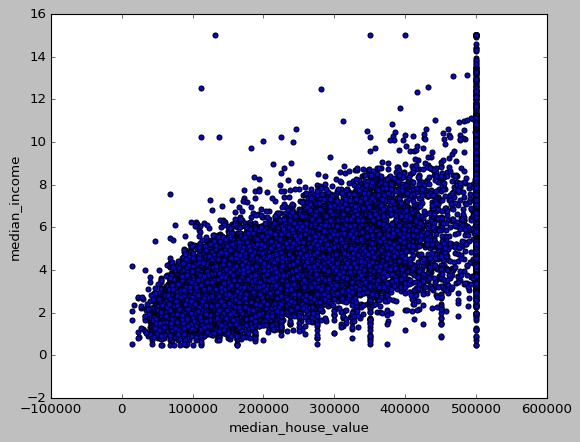

In [ ]:
df.plot.scatter(x='median_house_value',y='median_income')


<Axes: xlabel='median_house_value', ylabel='total_rooms'>

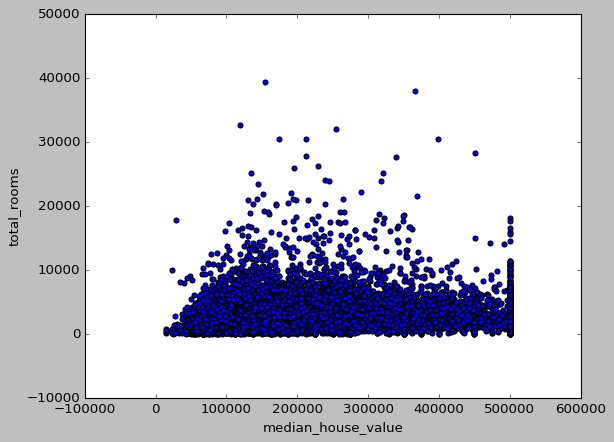

In [ ]:
df.plot.scatter(x='median_house_value',y='total_rooms')


<Axes: xlabel='median_house_value', ylabel='housing_median_age'>

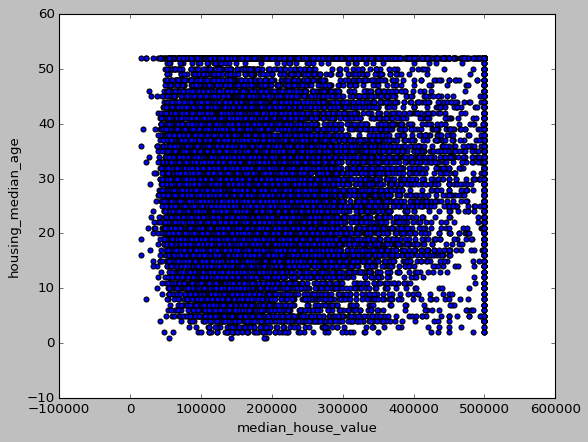

In [ ]:
df.plot.scatter(x='median_house_value',y='housing_median_age')


<Axes: xlabel='median_house_value', ylabel='median_income'>

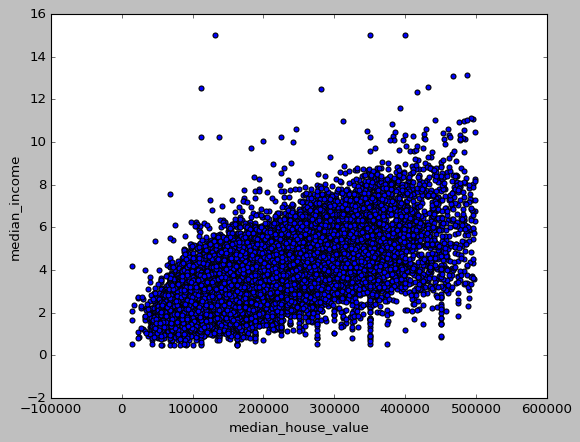

In [ ]:
df[df['median_house_value'] < 500000].plot.scatter(x='median_house_value',y='median_income')

<Axes: xlabel='median_house_value', ylabel='total_rooms'>

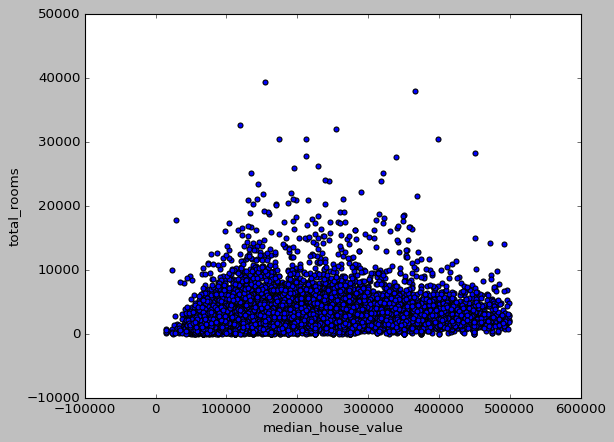

In [ ]:
df[df['median_house_value'] < 500000].plot.scatter(x='median_house_value',y='total_rooms')

<Axes: xlabel='median_house_value', ylabel='housing_median_age'>

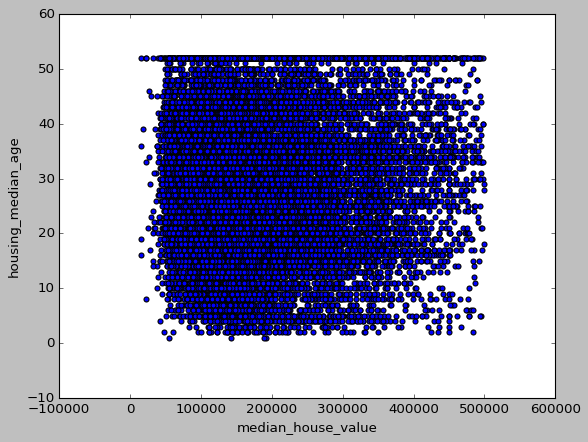

In [ ]:
df[df['median_house_value'] < 500000].plot.scatter(x='median_house_value',y='housing_median_age')

<Axes: xlabel='median_house_value', ylabel='housing_median_age'>

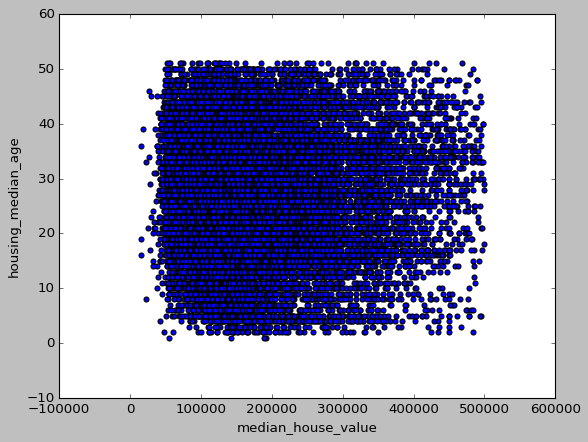

In [ ]:
df[(df['median_house_value'] < 500000)&
   (df['housing_median_age'] < 52)].plot.scatter(x='median_house_value',y='housing_median_age')

**`Visualização de Dados Geográficos`**

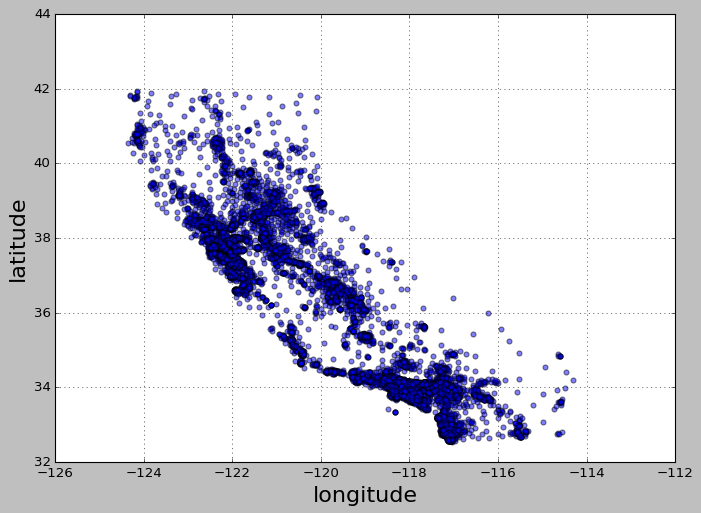

In [ ]:
# Set global label font size before plotting
plt.rcParams['axes.labelsize'] = 20

df.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.5,figsize=(10, 7))
plt.show()

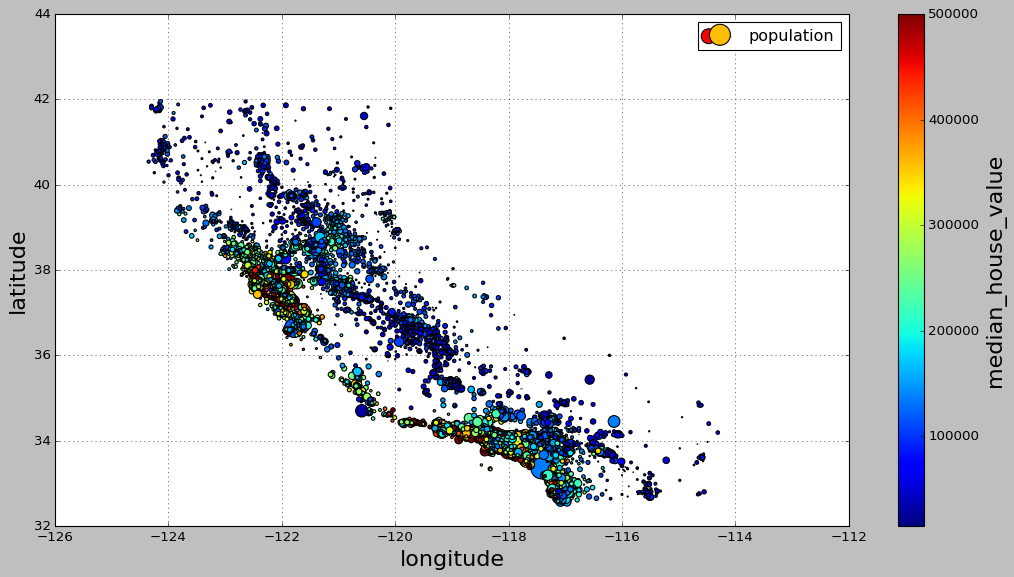

In [ ]:
# Set global label font size before plotting
plt.rcParams['axes.labelsize'] = 20

df.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=df["population"]/100, label="population",
             c="median_house_value", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(16, 8))
plt.show()

**`Mapa de Calor ou Heatmaps`**

<Axes: >

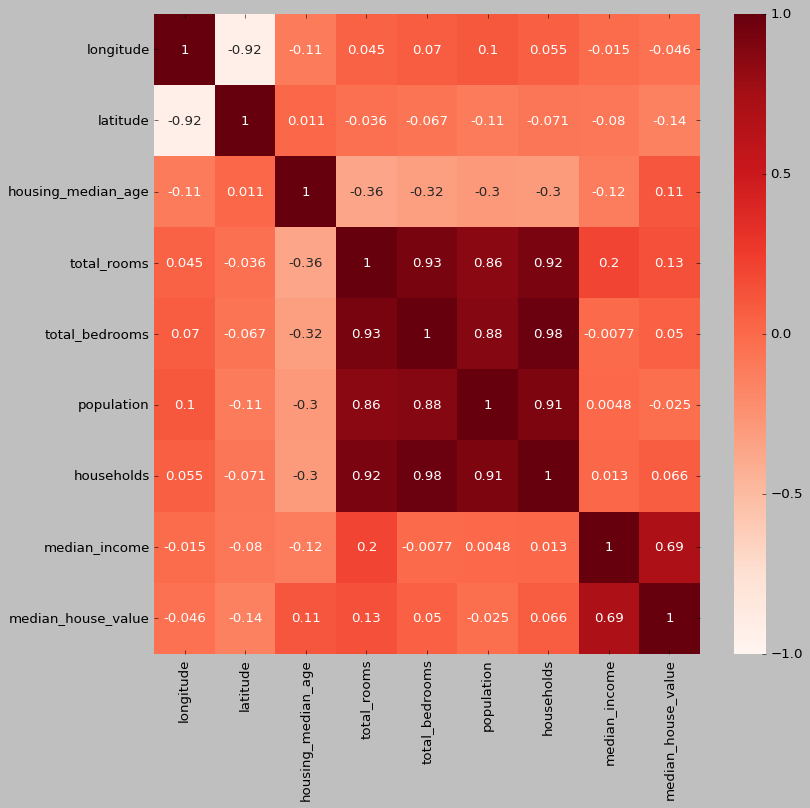

In [ ]:
mask = np.triu(np.ones_like(df[cols[:-1]].corr(), dtype=np.bool_))

fig, ax = plt.subplots(figsize=(11,10))

sns.heatmap(df[cols[:-1]].corr("pearson"), mask=None,
            cmap='Reds', vmin=-1, vmax=1, annot=True, ax=ax)

<Axes: >

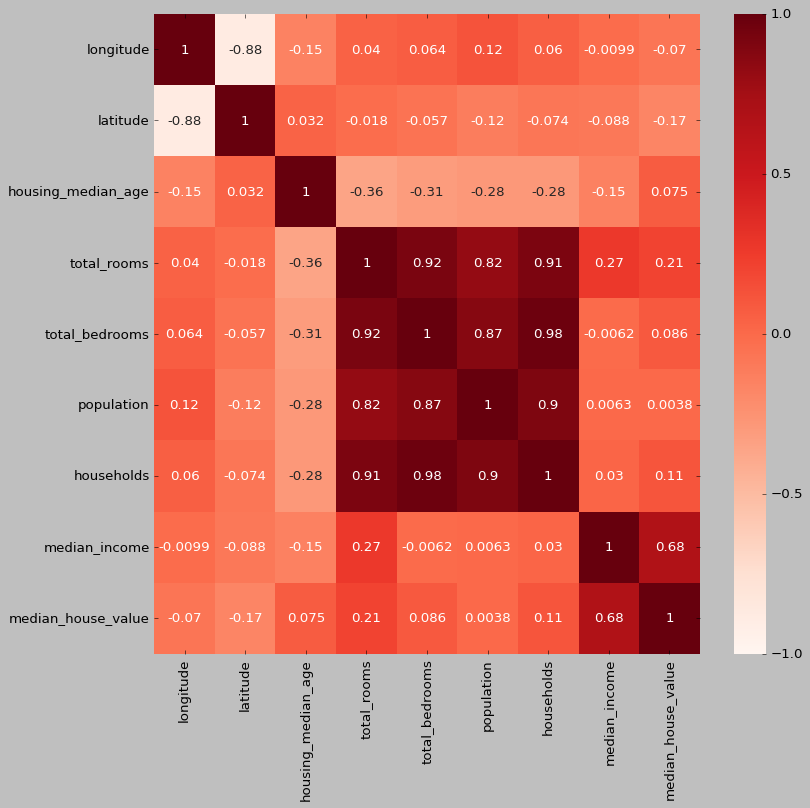

In [ ]:
mask = np.triu(np.ones_like(df[cols[:-1]].corr(), dtype=np.bool_))

fig, ax = plt.subplots(figsize=(11,10))

sns.heatmap(df[cols[:-1]].corr("spearman"), mask=None,
            cmap='Reds', vmin=-1, vmax=1, annot=True, ax=ax)

**Visualização de Dados Categóricos**

In [ ]:
df['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


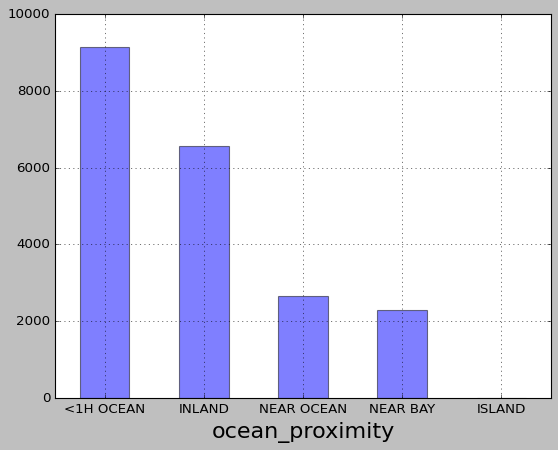

In [ ]:
df_categorical = df['ocean_proximity'].value_counts()

df_categorical.plot.bar(x='ocean_proximity', y='count', rot=0, grid=True, color='blue', alpha=0.5)
plt.show()